In [1]:
%load_ext mypy_ipython

In [2]:
from langgraph.graph import START, END, StateGraph, add_messages, MessagesState
from typing_extensions import TypedDict
from langchain_ollama import ChatOllama
from langchain_core.messages import HumanMessage, BaseMessage, AIMessage, RemoveMessage
from langchain_core.runnables import Runnable
from collections.abc import Sequence
from typing import Literal, Annotated

# The RemovingMessages State

## Using add_messages Function

In [3]:
my_list = add_messages()

## Define Nodes

In [4]:
chat = ChatOllama( model= 'llama3.2',seed=365, temperature=0, num_predict=256)

In [5]:
def ask_question(state: MessagesState) -> MessagesState:
     print(f"\n --------> ENTERING ask_question:")
     for i in state['messages']:
        i.pretty_print()
        
     question = "What is your question?"
     print(question)
     return MessagesState(messages = [AIMessage(question), HumanMessage(input())])

In [6]:
def ask_another_question(state: MessagesState) -> MessagesState:
     print(f"\n --------> ENTERING ask_another_question:")
     for i in state['messages']:
        i.pretty_print()
     question = "Would you like to ask one more question (yes/no)?"
     print(question)
     return MessagesState(messages = [AIMessage(question),HumanMessage(input())]) 

In [7]:
def chatbot(state: MessagesState) -> MessagesState:

    print(f"\n --------> ENTERING chatbot:")
    for i in state['messages']:
        i.pretty_print()
    response = chat.invoke(state['messages'])
    response.pretty_print()
    return MessagesState(messages = [response])

In [9]:
def trim_messages(state: MessagesState) -> MessagesState:
    print(f"\n-----> Entering trim_messages:")
    remove_messages = [RemovingMessages(id = i.id) for i in state["messages"][:-5]]

    return MessagesState(messages = remove_messages)

### Routing Function

In [12]:
def routing_function(state: MessagesState) -> Literal['trim_messages', "__end__"]:
    if state['messages'][-1].content == 'yes':
        return 'trim_messages'
    else:
        return "__end__"

### Define Graph

In [13]:
graph = StateGraph(MessagesState)

In [14]:
graph.add_node('ask_question', ask_question)
graph.add_node("chatbot", chatbot)
graph.add_node('ask_another_question', ask_another_question)
graph.add_node('trim_messages', trim_messages)

graph.add_edge(START, "ask_question")
graph.add_edge('ask_question', "chatbot")
graph.add_edge('chatbot', 'ask_another_question')
graph.add_conditional_edges(source='ask_another_question', path=routing_function)
graph.add_edge('trim_messages','ask_question')

In [15]:
graph_compiled = graph.compile()

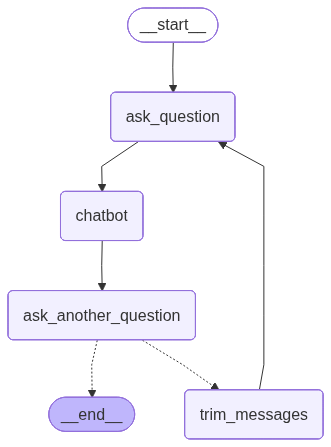

In [16]:
graph_compiled

In [17]:
graph_compiled.invoke(MessagesState(messages = []))


 --------> ENTERING ask_question:
What is your question?


 Who is the fastest man on planet Earth?



 --------> ENTERING chatbot:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

Who is the fastest man on planet Earth?
================================== Ai Message ==================================

The answer can be subjective and depend on various factors such as the specific event, distance, or conditions. However, according to the International Association of Athletics Federations (IAAF) and Guinness World Records, some of the fastest men in the world are:

1. Usain Bolt: Regarded by many as the greatest sprinter of all time, Bolt holds multiple world records in the 100m and 200m events with times of 9.58 seconds and 19.19 seconds, respectively.
2. Christian Coleman: An American sprinter who won the gold medal at the 2018 World Championships in the 100m event with a time of 9.69 seconds.
3. Noah Lyles: Another American sprinter who has set mult

 yes



-----> Entering trim_messages:

 --------> ENTERING ask_question:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

Who is the fastest man on planet Earth?
================================== Ai Message ==================================

The answer can be subjective and depend on various factors such as the specific event, distance, or conditions. However, according to the International Association of Athletics Federations (IAAF) and Guinness World Records, some of the fastest men in the world are:

1. Usain Bolt: Regarded by many as the greatest sprinter of all time, Bolt holds multiple world records in the 100m and 200m events with times of 9.58 seconds and 19.19 seconds, respectively.
2. Christian Coleman: An American sprinter who won the gold medal at the 2018 World Championships in the 100m event with a time of 9.69 seconds.
3. Noah Lyles: Anoth

 where was the fastest man born?



 --------> ENTERING chatbot:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

Who is the fastest man on planet Earth?
================================== Ai Message ==================================

The answer can be subjective and depend on various factors such as the specific event, distance, or conditions. However, according to the International Association of Athletics Federations (IAAF) and Guinness World Records, some of the fastest men in the world are:

1. Usain Bolt: Regarded by many as the greatest sprinter of all time, Bolt holds multiple world records in the 100m and 200m events with times of 9.58 seconds and 19.19 seconds, respectively.
2. Christian Coleman: An American sprinter who won the gold medal at the 2018 World Championships in the 100m event with a time of 9.69 seconds.
3. Noah Lyles: Another American sprinter who has set mult

 no


{'messages': [AIMessage(content='What is your question?', additional_kwargs={}, response_metadata={}, id='de29519b-8de2-473f-88cc-9ea10841c150'),
  HumanMessage(content='Who is the fastest man on planet Earth?', additional_kwargs={}, response_metadata={}, id='2c528fea-885f-4a1c-9547-bcd3cbecdff7'),
  AIMessage(content='The answer can be subjective and depend on various factors such as the specific event, distance, or conditions. However, according to the International Association of Athletics Federations (IAAF) and Guinness World Records, some of the fastest men in the world are:\n\n1. Usain Bolt: Regarded by many as the greatest sprinter of all time, Bolt holds multiple world records in the 100m and 200m events with times of 9.58 seconds and 19.19 seconds, respectively.\n2. Christian Coleman: An American sprinter who won the gold medal at the 2018 World Championships in the 100m event with a time of 9.69 seconds.\n3. Noah Lyles: Another American sprinter who has set multiple world rec